# Anomaly Detection with FiftyOne and Anomalib

## Setup

### Install dependencies

After this, install Anomalib and its dependencies. If you're running this in a colab notebook, the installation might take a few minutes, but local installation should be faster.

In [28]:
""" !pip install -U torchvision einops FrEIA timm open_clip_torch imgaug lightning kornia openvino git+https://github.com/openvinotoolkit/anomalib.git """

' !pip install -U torchvision einops FrEIA timm open_clip_torch imgaug lightning kornia openvino git+https://github.com/openvinotoolkit/anomalib.git '

Install Anomalib from source, per the instructions in the [Anomalib README](https://github.com/openvinotoolkit/anomalib?tab=readme-ov-file#-installation)

If you don't have it already installed, install FiftyOne. Make sure your version is `fiftyone>=0.23.8` so we can use the [Hugging Face Hub integration](https://docs.voxel51.com/integrations/huggingface.html#huggingface-hub) to load the MVTec AD dataset:

In [29]:
""" !pip install -U fiftyone """

' !pip install -U fiftyone '

Just a few more packages to install, and we're ready to go. Now you can see why we recommend using a virtual environment for this project!

- `huggingface_hub` for loading the MVTec AD dataset
- `clip` for computing image embeddings
- `umap-learn` for dimensionality reduction

In [30]:
""" !pip install -U huggingface_hub umap-learn git+https://github.com/openai/CLIP.git """

' !pip install -U huggingface_hub umap-learn git+https://github.com/openai/CLIP.git '

In [31]:
""" !pip install -U onnx """

' !pip install -U onnx '

### Load and Visualize the MVTec AD dataset

Now let's import all of the relevant modules we will need from FiftyOne:

In [32]:
import fiftyone as fo # base library and app
import fiftyone.brain as fob # ML methods
import fiftyone.zoo as foz # zoo datasets and models
from fiftyone import ViewField as F # helper for defining views
import fiftyone.utils.huggingface as fouh # Hugging Face integration
import os

And load the [MVTec AD dataset from the Hugging Face Hub](https://huggingface.co/datasets/Voxel51/mvtec-ad):

In [33]:
OBJECT = "vctim" 

In [34]:
# Initialize Dataset
if "vctim_dataset" in fo.list_datasets():
    fo.delete_dataset("vctim_dataset")
dataset = fo.Dataset("vctim_dataset")

samples = []
data_path = "../data/vctim"

train_dir = os.path.join(data_path, "train", "good")
if os.path.exists(train_dir):
    for file in os.listdir(train_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(train_dir, file))
            
            sample["split"] = "train"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["defect"] = fo.Classification(label="good") # No defect
            
            samples.append(sample)

test_good_dir = os.path.join(data_path, "test", "good")
if os.path.exists(test_good_dir):
    for file in os.listdir(test_good_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(test_good_dir, file))
            
            sample["split"] = "test"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["defect"] = fo.Classification(label="good")
            
            samples.append(sample)

test_bad_dir = os.path.join(data_path, "test", "bad")
if os.path.exists(test_bad_dir):
    for file in os.listdir(test_bad_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(test_bad_dir, file))
            
            sample["split"] = "test"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["defect"] = fo.Classification(label="vctim_missing") # Generic defect label
            
            samples.append(sample)

dataset.add_samples(samples)
print(f"Loaded {len(samples)} samples.")

 100% |█████████████████████| 7/7 [25.4ms elapsed, 0s remaining, 275.7 samples/s]     


INFO:eta.core.utils: 100% |█████████████████████| 7/7 [25.4ms elapsed, 0s remaining, 275.7 samples/s]     


Loaded 7 samples.


In [35]:
session = fo.launch_app(dataset)

The dataset has 5354 images across 12 object categories. Each category has "good" images and "anomalous" images with defects like scratches, dents, and holes. Each of the anomalous samples also has a mask which localizes the defective regions of the image.

The defect labels differ across categories, which is typical in real-world anomaly detection scenarios. In typical anomaly detection scenarios, you train a different model for each category. Here we'll go through the process for one category, and you can apply the same steps to other categories.

One more thing to note is that the dataset is split into training and test sets. The training set contains only "good" images, while the test set contains both "good" and "anomalous" images.

Before we train a model, let's dig into the dataset a bit more. We can get a feel for the structure and patterns hidden in our data by computing image embeddings and visualizing them in a lower-dimensional space. First, we'll compute embeddings for all the images in the dataset using the [CLIP model](https://github.com/openai/CLIP):

In [36]:
model = foz.load_zoo_model(
    "clip-vit-base32-torch"
)  # load the CLIP model from the zoo

# Compute embeddings for the dataset
dataset.compute_embeddings(
    model=model, embeddings_field="clip_embeddings", batch_size=64
)

# Dimensionality reduction using UMAP on the embeddings
fob.compute_visualization(
    dataset, embeddings="clip_embeddings", method="umap", brain_key="clip_vis"
)

 100% |█████████████████████| 7/7 [558.1ms elapsed, 0s remaining, 12.7 samples/s] 


INFO:eta.core.utils: 100% |█████████████████████| 7/7 [558.1ms elapsed, 0s remaining, 12.7 samples/s] 


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


UMAP( verbose=True)
Wed Dec 10 13:04:14 2025 Construct fuzzy simplicial set
Wed Dec 10 13:04:14 2025 Finding Nearest Neighbors
Wed Dec 10 13:04:14 2025 Finished Nearest Neighbor Search
Wed Dec 10 13:04:14 2025 Construct embedding


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Dec 10 13:04:14 2025 Finished embedding


Refresh the FiftyOne App, click the "+" tab, and select "Embeddings". Choose "all_clip_vis" from the dropdown menu. You'll see a scatter plot of the image embeddings in a 2D space, where each point corresponds to a sample in the dataset. Using the color-by dropdown, notice how the embeddings cluster based on the object category. This is because CLIP encodes semantic information about the images. Also note that *within* a category, CLIP embeddings don't cluster based on the defect type.

![CLIP Embeddings](https://github.com/voxel51/fiftyone/blob/main/docs/source/tutorials/images/anomaly_detection_clip_embeddings.gif?raw=1)

If instead we embed our images using a traditional computer vision model like ResNet, we also see some clustering within a category based on the defect type. However, as we established earlier, we will not have access to defect labels during inference. Instead, we'll use an unsupervised anomaly detection model.

In [37]:
model = foz.load_zoo_model(
    "resnet50-imagenet-torch"
)  # load the ResNet50 model from the zoo

# Compute embeddings for the dataset — this might take a while on a CPU
dataset.compute_embeddings(model=model, embeddings_field="resnet50_embeddings")

# Dimensionality reduction using UMAP on the embeddings
fob.compute_visualization(
    dataset,
    embeddings="resnet50_embeddings",
    method="umap",
    brain_key="resnet50_vis",
) 

 100% |█████████████████████| 7/7 [7.3s elapsed, 0s remaining, 1.0 samples/s]   


INFO:eta.core.utils: 100% |█████████████████████| 7/7 [7.3s elapsed, 0s remaining, 1.0 samples/s]   


Generating visualization...


INFO:fiftyone.brain.visualization:Generating visualization...
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\umap\umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


UMAP( verbose=True)
Wed Dec 10 13:04:22 2025 Construct fuzzy simplicial set
Wed Dec 10 13:04:22 2025 Finding Nearest Neighbors
Wed Dec 10 13:04:22 2025 Finished Nearest Neighbor Search
Wed Dec 10 13:04:22 2025 Construct embedding


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Wed Dec 10 13:04:22 2025 Finished embedding


💡 For deep dives into embeddings and dimensionality reduction, check out our tutorials:

- [Using Image Embeddings](https://docs.voxel51.com/tutorials/image_embeddings.html)
- [Visualizing Data with Dimensionality Reduction Techniques](https://docs.voxel51.com/tutorials/dimension_reduction.html)

## Train an Anomaly Detection Model

Now that we have a sense of the dataset, we're ready to train an anomaly detection model using Anomalib.

**Task**: Anomalib supports classification, detection, and segmentation tasks for images. We'll focus on segmentation, where the model predicts whether each pixel in the image is anomalous or not, creating a mask that localizes the defect.

**Model**: Anomalib supports a variety of anomaly detection algorithms, including [Deep Feature Kernel Density Estimation (DFKDE)](https://anomalib.readthedocs.io/en/v1.0.1/markdown/guides/reference/models/image/dfkde.html), [FastFlow](https://arxiv.org/abs/2111.07677), and [Reverse Distillation](https://arxiv.org/abs/2201.10703v2). For a complete list of supported algorithms, check out [Anomalib's reference guide](https://anomalib.readthedocs.io/en/v1.0.1/markdown/guides/reference/models/image/index.html). For this walkthrough, we'll use two algorithms:

- [PaDiM: a Patch Distribution Modeling Framework for Anomaly Detection and Localization](https://arxiv.org/abs/2011.08785)
- [PatchCore: Towards Total Recall in Industrial Anomaly Detection](https://arxiv.org/abs/2106.08265)

**Preprocessing**: For this walkthrough, we will resize the images to 256x256 pixels before training the model. Adding this as a transform via Torchvision's `Resize` class lets us resize the images on-the-fly during training and inference.

Import the necessary modules from Anomalib and helper modules for processing images and paths:

In [38]:
import numpy as np
import os
from pathlib import Path
from PIL import Image
from torchvision.transforms.v2 import Resize

In [39]:
from anomalib import TaskType
from anomalib.data import Folder
from anomalib.deploy import ExportType, OpenVINOInferencer
from anomalib.engine import Engine
from anomalib.models import Padim, Patchcore

Now define some constants to use throughout the notebook.

- `OBJECT`: The object category we'll focus on. For this walkthrough, we'll use "bottle". If you want to loop over categories, you can get the list of categories from the dataset with `dataset.distinct("category.label")`.
- `ROOT_DIR`: The root directory where Anomalib will look for images and masks. Our data is already stored on disk, so we will just symlink files to the directory Anomalib expects.
- `TASK`: The task we're performing. We'll use "segmentation" for this walkthrough.
- `IMAGE_SIZE`: The size to resize images to before training the model. We'll use $256$ x $256$ pixels.

In [40]:
ROOT_DIR = Path("./")
TASK = TaskType.CLASSIFICATION
IMAGE_SIZE = (256, 256)

For a given object type (category), the `create_datamodule()` function below creates an Anomalib  `DataModule` object. This will get passed into our engine's `fit()` method to train the model, and will be used to instantiate dataloaders for training and validation.

The code might look complex, so let's break down what's going on:

- We create subsets of our data containing only the "good" training images and "anomalous" images for validation.
- We symlink the images and masks to the directory Anomalib expects.
- We instantiate and setup a datamodule from Anomalib's `Folder`, which is the general-purpose class for custom datasets.

💡 It is also possible to create a torch `DataLoader` from scratch and pass it to the engine's `fit()` method. This gives you more control over the data loading process. This is left as an exercise for the reader 😉.

In [41]:
def create_datamodule(object_type, transform=None):
    ## Build transform
    if transform is None:
        transform = Resize(IMAGE_SIZE, antialias=True)

    normal_data = dataset.match(F("category.label") == object_type).match(
        F("split") == "train"
    )
    abnormal_data = (
        dataset.match(F("category.label") == object_type)
        .match(F("split") == "test")
        .match(F("defect.label") != "good")
    )

    normal_dir = Path(ROOT_DIR) / object_type / "normal"
    abnormal_dir = Path(ROOT_DIR) / object_type / "abnormal"
    
    # create directories if they do not exist
    os.makedirs(normal_dir, exist_ok=True)
    os.makedirs(abnormal_dir, exist_ok=True)

    if not os.path.exists(str(normal_dir)) or not os.listdir(str(normal_dir)):
        print(f"Exporting normal images to {normal_dir}...")
        normal_data.export(
            export_dir=str(normal_dir),
            dataset_type=fo.types.ImageDirectory,
            export_media="symlink",
        )

    for sample in abnormal_data.iter_samples():
        base_filename = sample.filename
        dir_name = os.path.dirname(sample.filepath).split(os.sep)[-1] 
        new_filename = f"{dir_name}_{base_filename}"
        
        if not os.path.exists(str(abnormal_dir / new_filename)):
            os.symlink(sample.filepath, str(abnormal_dir / new_filename))

    datamodule = Folder(
        name=object_type,
        root=ROOT_DIR,
        normal_dir=normal_dir,
        abnormal_dir=abnormal_dir,
        mask_dir=None, 
    )
    
    datamodule.setup()
    return datamodule

Now we can put it all together. The `train_and_export_model()` function below trains an anomaly detection model using Anomalib's `Engine` class, exports the model to OpenVINO, and returns the model "inferencer" object. The inferencer object is used to make predictions on new images.

In [42]:
from anomalib.deploy import ExportType, OpenVINOInferencer
import openvino as ov
def train_and_export_model(object_type, model, transform=None):
    engine = Engine()
    datamodule = create_datamodule(object_type, transform=transform)
    
    # Train the model
    engine.fit(model=model, datamodule=datamodule)

    # Export to ONNX (Bypassing the buggy OpenVINO direct export)
    print("Exporting to ONNX...")
    engine.export(model=model, export_type=ExportType.ONNX)
    
    # Define paths
    output_path = Path(engine.trainer.default_root_dir)
    onnx_path = output_path / "weights" / "onnx" / "model.onnx"
    
    # Manually convert ONNX to OpenVINO IR
    print("Converting ONNX to OpenVINO IR...")
    ov_output_dir = output_path / "weights" / "openvino"
    ov_output_dir.mkdir(parents=True, exist_ok=True)
    ov_model_path = ov_output_dir / "model.xml"
    
    core = ov.Core()
    ov_model = core.read_model(str(onnx_path))
    ov.save_model(ov_model, str(ov_model_path))
    
    # Initialize OpenVINO Inferencer
    inferencer = OpenVINOInferencer(
        path=ov_model_path,
        device="CPU"
    )
    return inferencer

Let's try this with `PaDiM` first. The training process should take less than a minute:

In [43]:
model = Padim()
inferencer = train_and_export_model(OBJECT, model)

            might be empty or devoid of either normal or anomalous images.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..
            might be empty or devoid of either normal or anomalous images.
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ PadimModel    │  2.8 M │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11                                                                         
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initialization.


c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'val_dataloader' to speed up the dataloader worker initialization.
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.
`Trainer.fit` stopped: `max_epochs=1` reached.


Exporting to ONNX...


c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\torch\onnx\_internal\torchscript_exporter\utils.py:1903: UserWarning: Provided key output for dynamic axes is not a valid input/output name
  warnings.warn(
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\anomalib\post_processing\post_processor.py:333: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  if not self._image_threshold.isnan():
c:\Users\rokeM\Downloads\Intel\Prj1\intel_vctim\Lib\site-packages\anomalib\post_processing\post_processor.py:319: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not general

Converting ONNX to OpenVINO IR...


In [44]:
dataset = fo.load_dataset("vctim_dataset")
test_split = dataset.match(F("category.label") == OBJECT).match(F("split") == "test")
test_image = Image.open(test_split.first().filepath)
print("Fields in test split:", test_split.get_field_schema().keys())

Fields in test split: odict_keys(['id', 'filepath', 'tags', 'metadata', 'created_at', 'last_modified_at', 'split', 'category', 'defect', 'clip_embeddings', 'resnet50_embeddings'])


The output contains a scalar anomaly score `pred_score`, a `pred_mask` denoting the predicted anomalous regions, and a heatmap `anomaly_map` showing the anomaly scores for each pixel. This is all valuable information for understanding the model's predictions. The `run_inference()` function below will take a FiftyOne sample collection (e.g. our test set) as input, along with the inferencer object, and a key for storing the results in the samples. It will run the model on each sample in the collection and store the results. The `threshold` argument acts as a cutoff for the anomaly score. If the score is above the threshold, the sample is considered anomalous. In this example, we'll use a threshold of $0.5$, but you can experiment with different values.

In [45]:
def run_inference(sample_collection, inferencer, key, threshold=0.5):
    for sample in sample_collection.iter_samples(autosave=True, progress=True):
        output = inferencer.predict(image=Image.open(sample.filepath))

        conf = output.pred_score
        anomaly = "normal" if conf < threshold else "vctim_missing"

        sample[f"pred_anomaly_score_{key}"] = conf
        sample[f"pred_anomaly_{key}"] = fo.Classification(label=anomaly)
        sample[f"pred_anomaly_map_{key}"] = fo.Heatmap(map=output.anomaly_map)
        sample[f"pred_defect_mask_{key}"] = fo.Segmentation(mask=output.pred_mask)

In [46]:
run_inference(test_split, inferencer, "padim")

 100% |█████████████████████| 4/4 [686.4ms elapsed, 0s remaining, 5.8 samples/s]      


INFO:eta.core.utils: 100% |█████████████████████| 4/4 [686.4ms elapsed, 0s remaining, 5.8 samples/s]      


Let's visualize these results in the FiftyOne App:


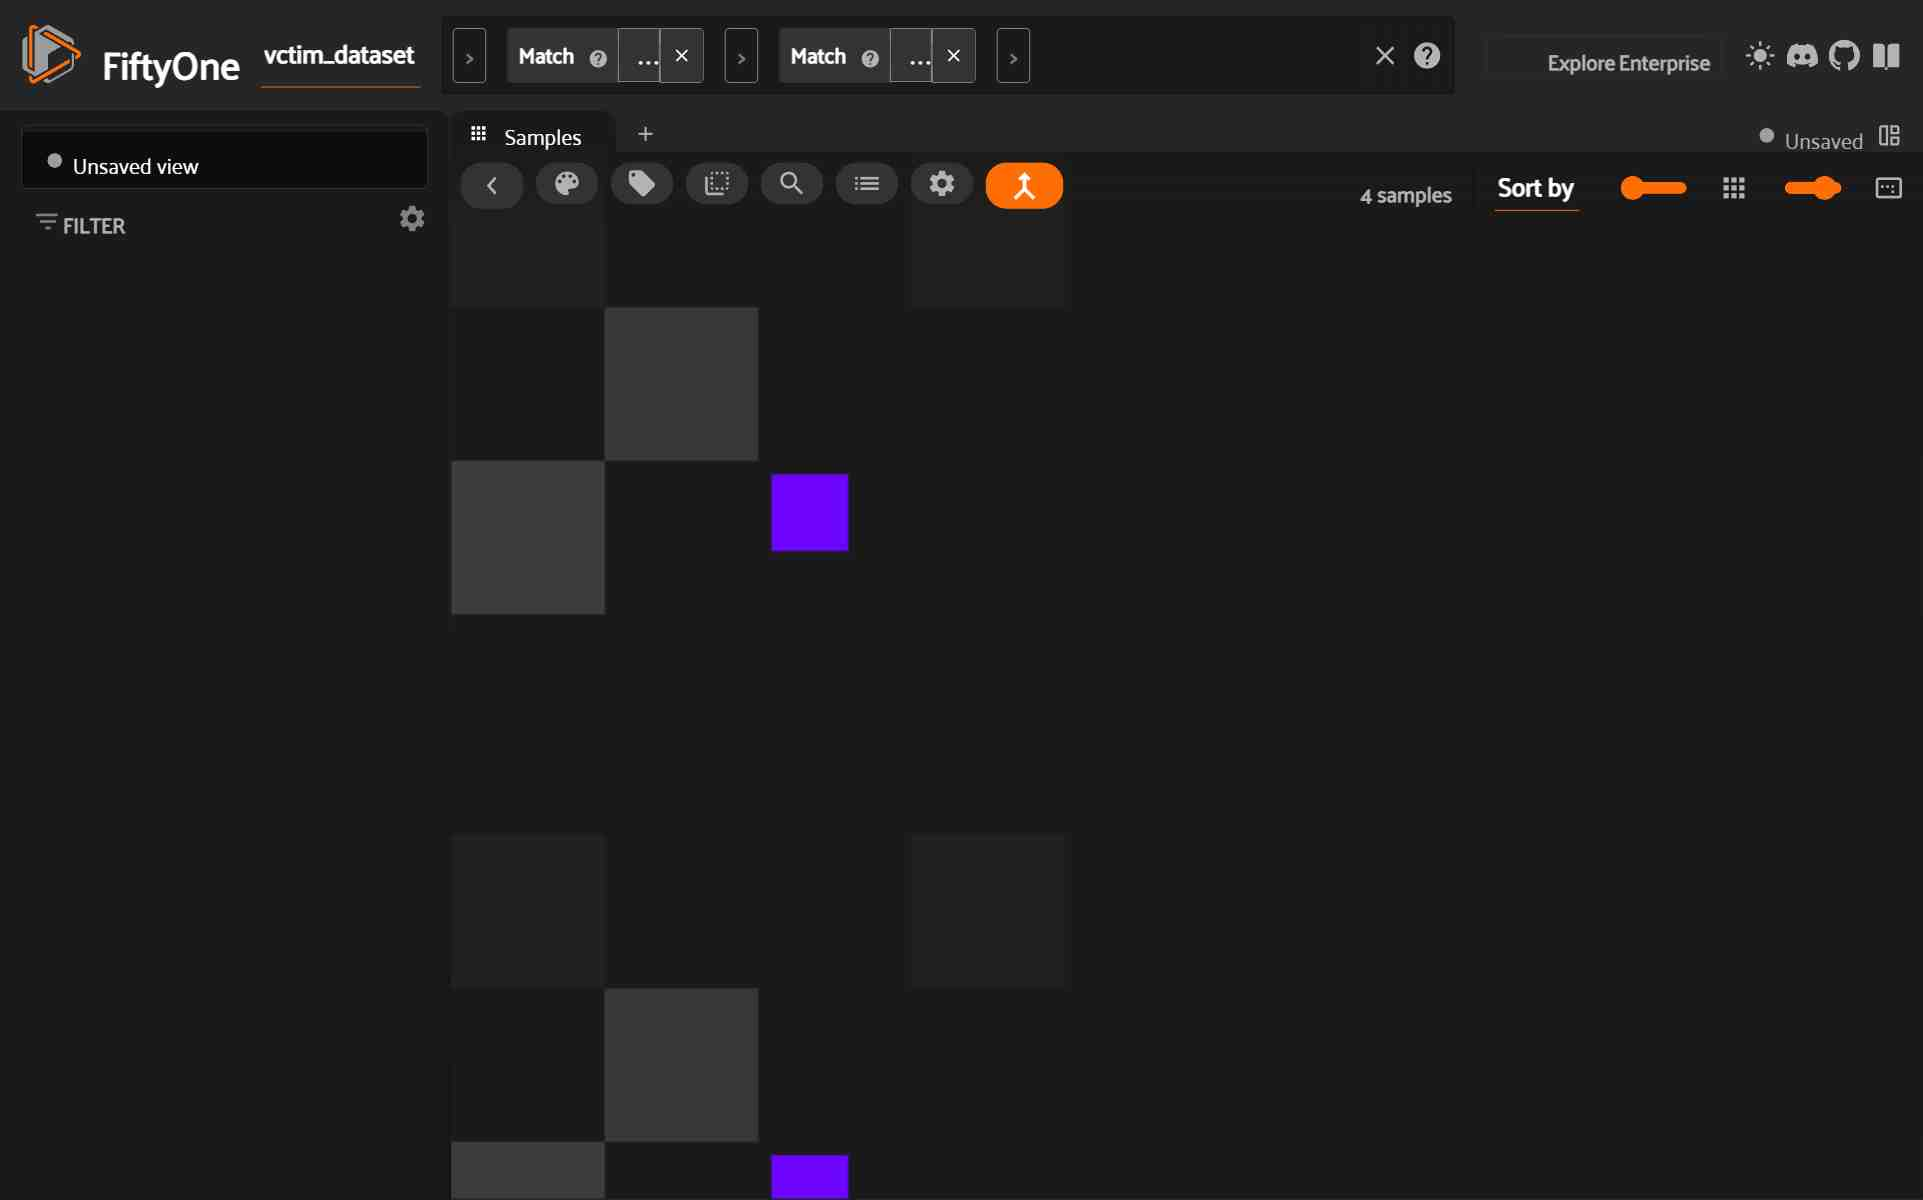

In [47]:
session = fo.launch_app(view=test_split)

## Evaluate Anomaly Detection Models

We have an anomaly detection model, but how do we know if it's any good? For one, we can evaluate the model using metrics like precision, recall, and F1 score. FiftyOne's [Evaluation API](https://docs.voxel51.com/user_guide/evaluation.html#) makes this easy. We are going to evaluate the full-image classification performance of the model, as well as the segmentation performance.

We need to prepare our data for evaluation. First, we need to add null masks for the "normal" images to ensure the evaluation is fair:

In [48]:
for sample in test_split.iter_samples(autosave=True, progress=True):
    if sample["defect"].label == "good":
        sample["defect_mask"] = fo.Segmentation(
            mask=np.zeros_like(sample["pred_defect_mask_padim"].mask)
        )

 100% |█████████████████████| 4/4 [45.6ms elapsed, 0s remaining, 87.7 samples/s] 


INFO:eta.core.utils: 100% |█████████████████████| 4/4 [45.6ms elapsed, 0s remaining, 87.7 samples/s] 


We also need to ensure consistency in naming/labels between ground truth and predictions. We'll rename all of our "good" images to "normal" and every type of anomaly to "anomaly":

In [49]:
old_labels = test_split.distinct("defect.label")
label_map = {label:"vctim_missing" for label in old_labels if label != "good"}
label_map["good"] = "normal"
mapped_view = test_split.map_labels("defect", label_map)

In [50]:
session.view = mapped_view.view()

![Mapped View](https://github.com/voxel51/fiftyone/blob/main/docs/source/tutorials/images/anomaly_detection_mapped_labels.jpg?raw=1)

For classification, we'll use binary evaluation, with "normal" as the negative class and "anomaly" as the positive class:

In [51]:
eval_classif_padim = mapped_view.evaluate_classifications(
    "pred_anomaly_padim",
    gt_field="defect",
    eval_key="eval_classif_padim",
    method="binary",
    classes=["normal", "anomaly"],
)

In [52]:
eval_classif_padim.print_report()

              precision    recall  f1-score   support

      normal       0.75      1.00      0.86         3
     anomaly       0.00      0.00      0.00         0

   micro avg       0.75      1.00      0.86         3
   macro avg       0.38      0.50      0.43         3
weighted avg       0.75      1.00      0.86         3



The model performs quite well on the classification task!

If we go back over to the app and sort by anomaly score, we can see that certain types of anomalies tend to have higher scores than others. In this example, `contamination` instances tend to have either very high or very low scores relative to `broken_small` and `broken_large`. When we put this model in production we might be more likely to miss certain types of anomalies. Other types of models, or ensembles of models, might be more robust to this!